# Comparativa de Clustering: K-Means, DBSCAN y Jerárquico

**Objetivo:** comparar tres métodos de clustering en un dataset real y elegir **el mejor** según el **coeficiente de silueta** (y **Elbow** solo para K-Means).

**Dataset elegido:** **Palmer Penguins** (medidas de pingüinos) — datos libres y fáciles de obtener.

- Página del proyecto: <https://allisonhorst.github.io/palmerpenguins/>
- CSV directo (penguins_clean): <https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins_clean.csv>

> Nota: **NO uses la columna de especie** (`species`) para entrenar (clustering es no supervisado). Se puede usr más tarde sólo para **interpretación** si lo deseas, pero **nunca** para ajustar los modelos.


## Requisitos
- Trabajar siempre con **variables numéricas** y **datos escalados**.
- Evaluación:
  - **K-Means:** curva **Elbow** (inercia) para k=2..10 + **Silhouette** para k=2..10.
  - **DBSCAN:** probar varias combinaciones de `eps` y `min_samples`; reportar **Silhouette**, nº de clústeres (excl. ruido) y % ruido.
  - **Jerárquico:** probar `linkage` en {`ward`, `complete`, `average`} y k=2..10; reportar **Silhouette**.
- Conclusión final: elige método y configuración (parámetros) y justifica **en 8–12 líneas**.

**Importante (API de scikit-learn):**
- `KMeans` **sí** tiene `.predict(X)` para etiquetar nuevos puntos.
- `DBSCAN` y `AgglomerativeClustering` **no** tienen `.predict`. Usa `fit_predict(X)` y el atributo `.labels_` tras el ajuste.


## 0) Preparación del entorno
- Necesitas tener instalado `pandas`, `numpy`, `scikit-learn`, `matplotlib`.
- Fija `random_state=42` (u otro) cuando aplique para reproducibilidad.


In [2]:
random_state = 777
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

## 1) Descarga y carga de datos
1. Descarga el CSV desde la URL indicada.
2. Cárgalo en un `DataFrame`.
3. Inspecciona forma, nombres de columnas y tipos.
4. Identifica columnas **numéricas** que usarás como `X` (excluye `species` y otras no numéricas).


In [3]:
df = pd.read_csv(url)
df = df.dropna()
df = df.drop_duplicates()

df_sincat = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

print(df_sincat.head())
print(df_sincat.info())
print(df.describe())

X_numericas = df_sincat.select_dtypes(include=[np.number]).copy()
X_onehot = df_sincat[['island_Dream', 'island_Torgersen', 'sex_MALE']].astype(int).copy()
y = df['species'].copy()


print("Datos numericos (X) and especie/target (y):")
print(X_numericas.head())
print(X_onehot.head())
print(y.head())



  species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Adelie            39.1           18.7              181.0       3750.0   
1  Adelie            39.5           17.4              186.0       3800.0   
2  Adelie            40.3           18.0              195.0       3250.0   
4  Adelie            36.7           19.3              193.0       3450.0   
5  Adelie            39.3           20.6              190.0       3650.0   

   island_Dream  island_Torgersen  sex_MALE  
0         False              True      True  
1         False              True     False  
2         False              True     False  
4         False              True     False  
5         False              True      True  
<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   bill_length_mm     

## 2) Limpieza mínima y normalización
1. Elimina duplicados y filas con nulos en las columnas numéricas escogidas.
2. **Estandariza** (`StandardScaler`) para tener media 0 y varianza 1.
3. Guarda el array escalado como `X_scaled` (será tu base para todos los modelos).

> **Por qué escalamos:** Todas las distancias (Euclídeas) y medidas de densidad de los modelos dependen de la escala; mezclar variables en escalas distintas sesga los resultados.


In [4]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numericas)
print(X_numericas.shape, '->', X_scaled.shape)

X_final = np.hstack((X_scaled, X_onehot.values))

(333, 4) -> (333, 4)


## 3) K-Means
**Objetivo:**
- Bucle `k` en 2..10.
- Guardar por cada `k`: **inercia** (suma de distancias al centroide) y **Silhouette**.
- Seleccionar `k` final apoyándote en **Elbow** + **Silhouette**.

**Indicaciones específicas:**
- Usa `KMeans(n_clusters=k, random_state=42)`.
- Tras ajustar, obtén etiquetas con `.labels_` o usando `.predict(X_scaled)`.
- Para Silhouette: `sklearn.metrics.silhouette_score(X_scaled, labels)`.
- Traza **Inercia vs k** y **Silhouette vs k** (dos gráficos separados). Explica en 2-3 líneas tu elección de `k`.


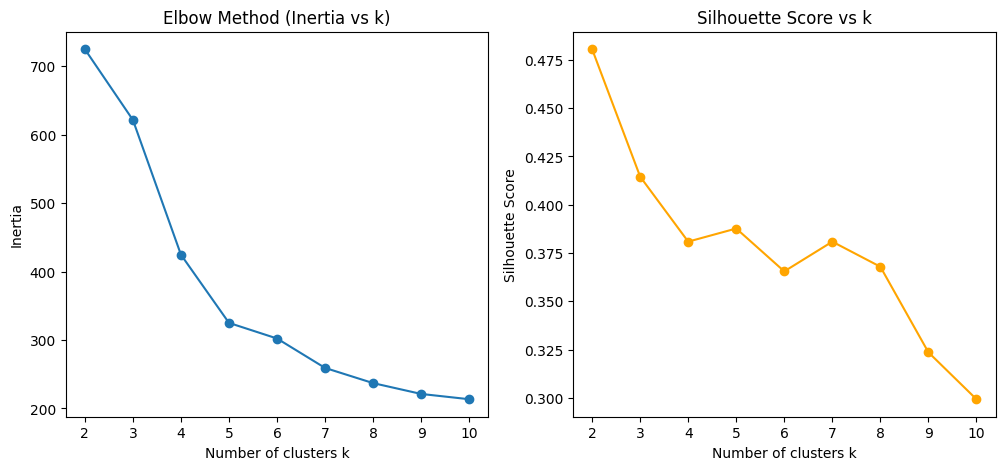

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans= KMeans(n_clusters = k, random_state=random_state)
    kmeans.fit(X_final)
    labels = kmeans.labels_
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_final, labels)
    silhouettes.append(sil_score)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method (Inertia vs k)')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.subplot(1,2,2)
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.show()

### Para K-Means la mejor cantidad de clusters segun la score de Silhouettees de 2 cluster, podriamos considerar otras opciones viendo las inercias y ya que estamos sesgados por saber el resultado que es 3.

## 4) DBSCAN
**Objetivo:** explorar `eps` y `min_samples` en una rejilla pequeña y comparar resultados.

**Indicaciones específicas:**
- Probar `eps` en valores razonables (por ejemplo: 0.3, 0.5, 0.7, 0.9) y `min_samples` en {3, 5, 7}.
- Para cada combinación: ajusta con `DBSCAN(eps=?, min_samples=?)` sobre `X_scaled`.
- Extrae etiquetas con `.labels_`.
- Calcula **nº de clústeres** (excluyendo `-1`) y **% de ruido** (`label == -1`).
- Calcula **Silhouette** **solo si** hay al menos **2** clústeres válidos (sin contar ruido). Si no, anota "no aplicable".
- Elige una combinación final y justifica.


In [6]:
# TODO: Grid pequeño de DBSCAN: probar eps y min_samples
# TODO: Para cada combinación, registrar #clusters válidos, %ruido y silhouette (si aplica)
# TODO: Elegir configuración final; obtener labels_dbscan

from sklearn.cluster import DBSCAN

silhouette_scores_dbscan = []
n_clusters_dbscan = []
noise_percentages = []
eps_values = np.arange(0.3 , 2.1, 0.2)
min_samples_values = [3, 5, 7]

mejor_eps = None
mejor_min_samples = None
mejor_silhouette = -777
ruido_del_mejor = None
n_cluster_del_mejor = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels_dbscan = dbscan.fit_predict(X_final)
        n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
        n_clusters_dbscan.append(n_clusters)
        n_noise = list(labels_dbscan).count(-1)
        noise_percentage = n_noise / len(labels_dbscan)
        noise_percentages.append(noise_percentage)
        if n_clusters > 1:
            sil_score = silhouette_score(X_final, labels_dbscan)
            if sil_score > mejor_silhouette:
                mejpor_silhouette = sil_score
                mejor_eps = eps
                mejor_min_samples = min_samples
                ruido_del_mejor = noise_percentage
                n_cluster_del_mejor = n_clusters
        else:
            sil_score = -1
        silhouette_scores_dbscan.append(sil_score)


print("Mejor silhouette DBSCAN:", max(silhouette_scores_dbscan))
print("Ruido", ruido_del_mejor)
print("N clusters:", n_cluster_del_mejor)
print("Parametros eps y min_samples:", round(mejor_eps, 2), mejor_min_samples)


Mejor silhouette DBSCAN: 0.48049391550433956
Ruido 0.0
N clusters: 2
Parametros eps y min_samples: 1.7 7


## 5) Aglomerativo Jerárquico
**Objetivo:** probar distintas reglas de enlace y diferentes `k`.

**Indicaciones específicas:**
- Probar `linkage` en {`ward`, `complete`, `average`}.
- Para cada `linkage`, probar `n_clusters` en 2..10.
- Ajustar con `AgglomerativeClustering(n_clusters=k, linkage=..., metric='euclidean')`.
- Obtener etiquetas con `.fit_predict(X_scaled)` o del atributo `.labels_`.
- Calcular **Silhouette** y registrar los resultados en una tabla.
- Elegir la pareja (linkage, k) final y justificar.

> Recordatorio: `ward` requiere métrica euclídea (en scikit-learn es implícita). No hay `.predict()` para nuevos datos.


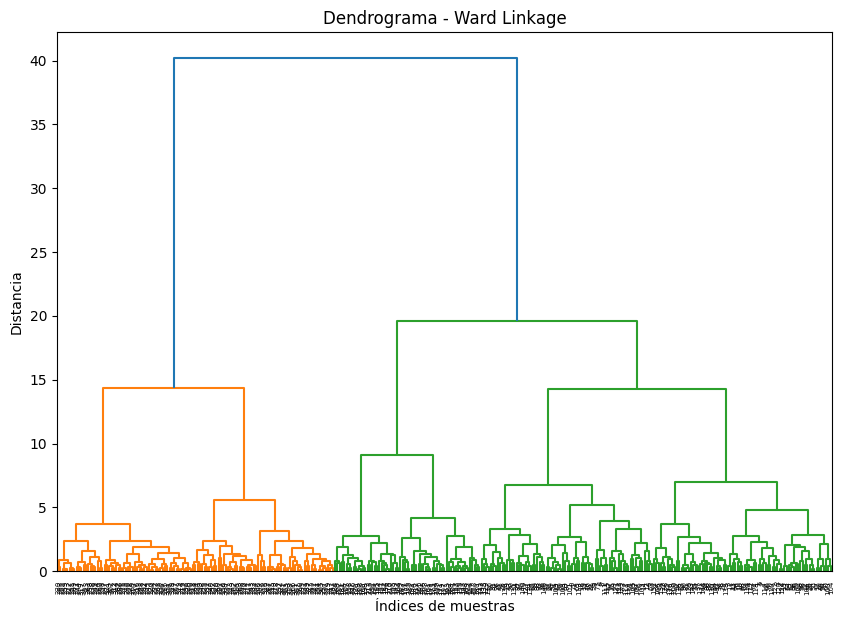

Silhouette Agglomerative (ward, k=2): 0.48049391550433956


In [7]:
# TODO: Bucle Agglomerative: linkage en {'ward','complete','average'} y k=2..10
# TODO: Calcular silhouette para cada combinación y elegir la mejor; obtener labels_agglom

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

Z = linkage(X_final, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrograma - Ward Linkage')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia')
plt.show()

agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglom = agglo.fit_predict(X_final)
sil_score_agglo = silhouette_score(X_final, labels_agglom)
print("Silhouette Agglomerative (ward, k=2):", sil_score_agglo)

## 6) Comparativa y Conclusión
1. Resume en una **tabla** el **mejor** resultado de cada método (método, parámetros, silhouette, nº de clústeres y notas relevantes como % ruido en DBSCAN).
2. Escribe una **conclusión de 8–12 líneas** justificando el **método ganador** para estos datos y por qué descartas las alternativas (forma de clústeres, sensibilidad a parámetros, presencia de ruido/outliers, etc.).


In [8]:
tabla_comparativa = pd.DataFrame({
    'Método': ['KMeans', 'DBSCAN', 'Agglomerative'],
    'Parámetros': ['k=3', f'eps={round(mejor_eps,2)}, k = {n_cluster_del_mejor} ,  min_samples={mejor_min_samples}', 'linkage=ward, k=2'],
    'Silhouette Score': [max(silhouettes), max(silhouette_scores_dbscan), sil_score_agglo],
    'Ruido (%)': ['-', f'{round(ruido_del_mejor*100,2)}%', '-']
})

print(tabla_comparativa)

          Método                       Parámetros  Silhouette Score Ruido (%)
0         KMeans                              k=3          0.480494         -
1         DBSCAN  eps=1.7, k = 2 ,  min_samples=7          0.480494      0.0%
2  Agglomerative                linkage=ward, k=2          0.480494         -


### Conclusión

Seleccionar un metodo en específico es complicado ya que los mejores modelos de cada metodo tiene la misma Silhouette score. Aun así el método ganador es DBSCAN debido a su capacidad para identificar la estructuras de los datos y manejar eficientemente el ruido. Aunque todos los métodos comparten el mismo Silhouette Score (0.480494), lo que me ha inclinado hacia el método DBSCAN es esta métrica con 0% de ruido, demostrando una agrupación más pura. K-Means y Agglomerative Clustering asumen clústeres esféricos y de tamaño similar, lo que puede forzar agrupaciones artificiales. Además, estos métodos no diferencian entre outliers y puntos válidos, incorporando potencialmente ruido en los clústeres. DBSCAN, en cambio, detecta automáticamente la densidad y separa el ruido, siendo más robusto ante agrupaciones menos estructurados o globulares. Su sensibilidad a parámetros como eps queda justificada aquí al encontrar una configuración óptima. Por ello, para estos datos, DBSCAN es superior en forma de clústeres y tratamiento de outliers.

---
## Tips rápidos
- **Escala siempre** antes de ajustar los modelos.
- Si la Silhouette es negativa o muy baja, revisa parámetros.
- En DBSCAN, `eps` muy pequeño -> muchos ruidos; `eps` muy grande -> pocos clústeres (puede mezclarlo todo).
- K-Means es sensible a outliers; DBSCAN puede marcarlos como ruido; el jerárquico con `complete` favorece clústeres compactos.
- Documenta tus decisiones (por qué ese `k`, ese `eps`, ese `linkage`).


# BONUS EXTRA

### Validación tramposa

Usa la columna species para evaluar qué tan “puras” son las asignaciones del mejor modelo de cada método.

Creando una matriz de confusión entre clúster y especie y sacando accuracy.

Comenta usando distintos valores de eps y min_samples en DBSCAN.

### Detección de anomalías con DBSCAN

Con tu configuración de DBSCAN, analiza los puntos con label = -1 (ruido): ¿qué tienen en común (rangos extremos de masa, culmen, etc.)?

Genera una tabla o un par de graficas (histogramas comparativos, por ejemplo) para ilustrar las diferencias entre los puntos de ruido y los puntos asignados a clústeres.


Accuracy DBSCAN (eps = 1.7, min_samples = 7): 0.43843843843843844
Accuracy optimizada DBSCAN (eps = 1.7, min_samples = 7): 0.7957957957957958
Silhouette optimizada DBSCAN (eps = 1.7, min_samples = 7): 0.48049391550433956


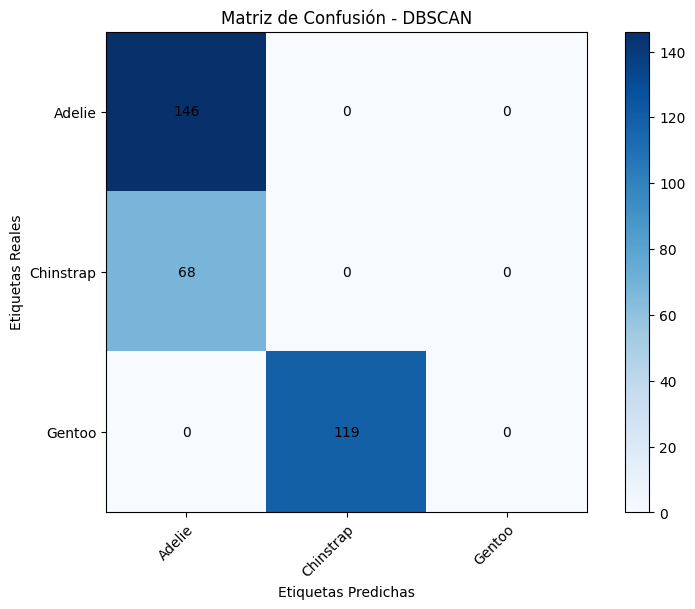

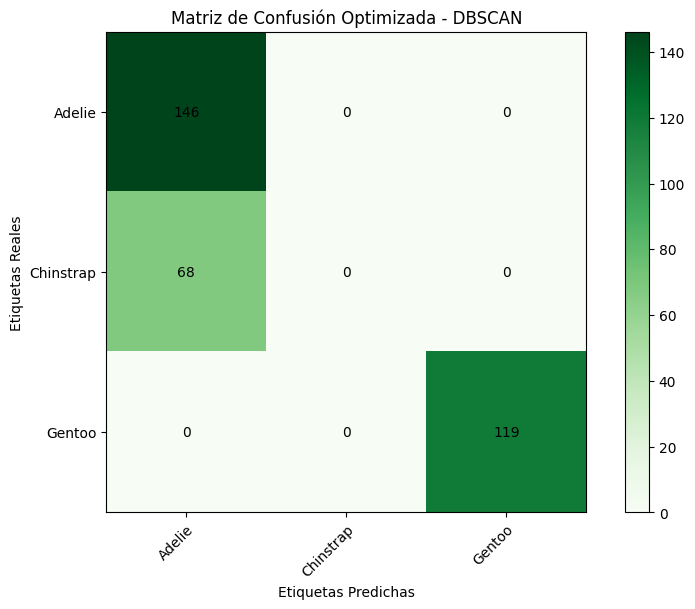

Matriz de Confusión para DBSCAN (eps=0.5, min_samples=3):
Accuracy DBSCAN (eps = 0.5, min_samples = 3): 0.015015015015015015
Matriz de Confusión para DBSCAN (eps=0.5, min_samples=5):
Accuracy DBSCAN (eps = 0.5, min_samples = 5): 0.04804804804804805
Matriz de Confusión para DBSCAN (eps=0.5, min_samples=7):
Accuracy DBSCAN (eps = 0.5, min_samples = 7): 0.09009009009009009
Matriz de Confusión para DBSCAN (eps=1.0, min_samples=3):
Accuracy DBSCAN (eps = 1.0, min_samples = 3): 0.06906906906906907
Matriz de Confusión para DBSCAN (eps=1.0, min_samples=5):
Accuracy DBSCAN (eps = 1.0, min_samples = 5): 0.07207207207207207
Matriz de Confusión para DBSCAN (eps=1.0, min_samples=7):
Accuracy DBSCAN (eps = 1.0, min_samples = 7): 0.07207207207207207
Matriz de Confusión para DBSCAN (eps=1.5, min_samples=3):
Accuracy DBSCAN (eps = 1.5, min_samples = 3): 0.43843843843843844
Matriz de Confusión para DBSCAN (eps=1.5, min_samples=5):
Accuracy DBSCAN (eps = 1.5, min_samples = 5): 0.43843843843843844
Matriz 

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.optimize import linear_sum_assignment

#Primero matriz de confusión y accuracy para DBSCAN con los mejores parámetros

dbscan = DBSCAN(eps=1.7 , min_samples=7)
labels_dbscan_maxs = dbscan.fit_predict(X_final)
#print (labels_dbscan)

y_numerica = y.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}).values
#print(y_numerica)


matriz_confusion_maxs = confusion_matrix(y_numerica, labels_dbscan_maxs)
#print(matriz_confusion)


accuracy_maxs = accuracy_score(y_numerica, labels_dbscan_maxs)

print("Accuracy DBSCAN (eps = 1.7, min_samples = 7):", accuracy_maxs)

#Ahora mediante el algoritmo húngaro, alineamos las etiquetas obtenidas con las reales para calcular un accuracy
row_ind, col_ind = linear_sum_assignment(-matriz_confusion_maxs)
matriz_confusion_optimizada = matriz_confusion_maxs[:, col_ind]
accuracy_optimizada = np.trace(matriz_confusion_optimizada) / np.sum(matriz_confusion_optimizada)
print("Accuracy optimizada DBSCAN (eps = 1.7, min_samples = 7):", accuracy_optimizada)

#Ahora obtenemos la Silhouette con las etiquetas optimizadas
labels_dbscan_optimizada = np.zeros_like(labels_dbscan_maxs)
for i, j in zip(row_ind, col_ind):
    labels_dbscan_optimizada[labels_dbscan_maxs == j] = i
silhouette_optimizada = silhouette_score(X_final, labels_dbscan_optimizada)
print("Silhouette optimizada DBSCAN (eps = 1.7, min_samples = 7):", silhouette_optimizada)


# Plotear como de cerca estan las etiquetas obtenidas con las reales
etiquetas = ['Adelie', 'Chinstrap', 'Gentoo']
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_confusion_maxs, cmap='Blues')
ax.set_xticks(np.arange(len(etiquetas)))
ax.set_yticks(np.arange(len(etiquetas)))
ax.set_xticklabels(etiquetas)
ax.set_yticklabels(etiquetas)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        text = ax.text(j, i, matriz_confusion_maxs[i, j], ha="center", va="center", color="black")
ax.set_title("Matriz de Confusión - DBSCAN")
fig.tight_layout()
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.colorbar(im)
plt.show()

#Plotear como de cerca estan las etiquetas optimizadas obtenidas con las reales
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_confusion_optimizada, cmap='Greens')
ax.set_xticks(np.arange(len(etiquetas)))
ax.set_yticks(np.arange(len(etiquetas)))
ax.set_xticklabels(etiquetas)
ax.set_yticklabels(etiquetas)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        text = ax.text(j, i, matriz_confusion_optimizada[i, j], ha="center", va="center", color="black")
ax.set_title("Matriz de Confusión Optimizada - DBSCAN")
fig.tight_layout()
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.colorbar(im)
plt.show()

#Prueba de todas las combinaciones de DBSCAN y mostrar su accuracy

for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_samples in [3, 5, 7]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels_dbscan = dbscan.fit_predict(X_final)
        matriz_confusion = confusion_matrix(y_numerica, labels_dbscan)
        print(f"Matriz de Confusión para DBSCAN (eps={eps}, min_samples={min_samples}):")
        accuracy = accuracy_score(y_numerica, labels_dbscan)
        print(f"Accuracy DBSCAN (eps = {eps}, min_samples = {min_samples}):", accuracy)


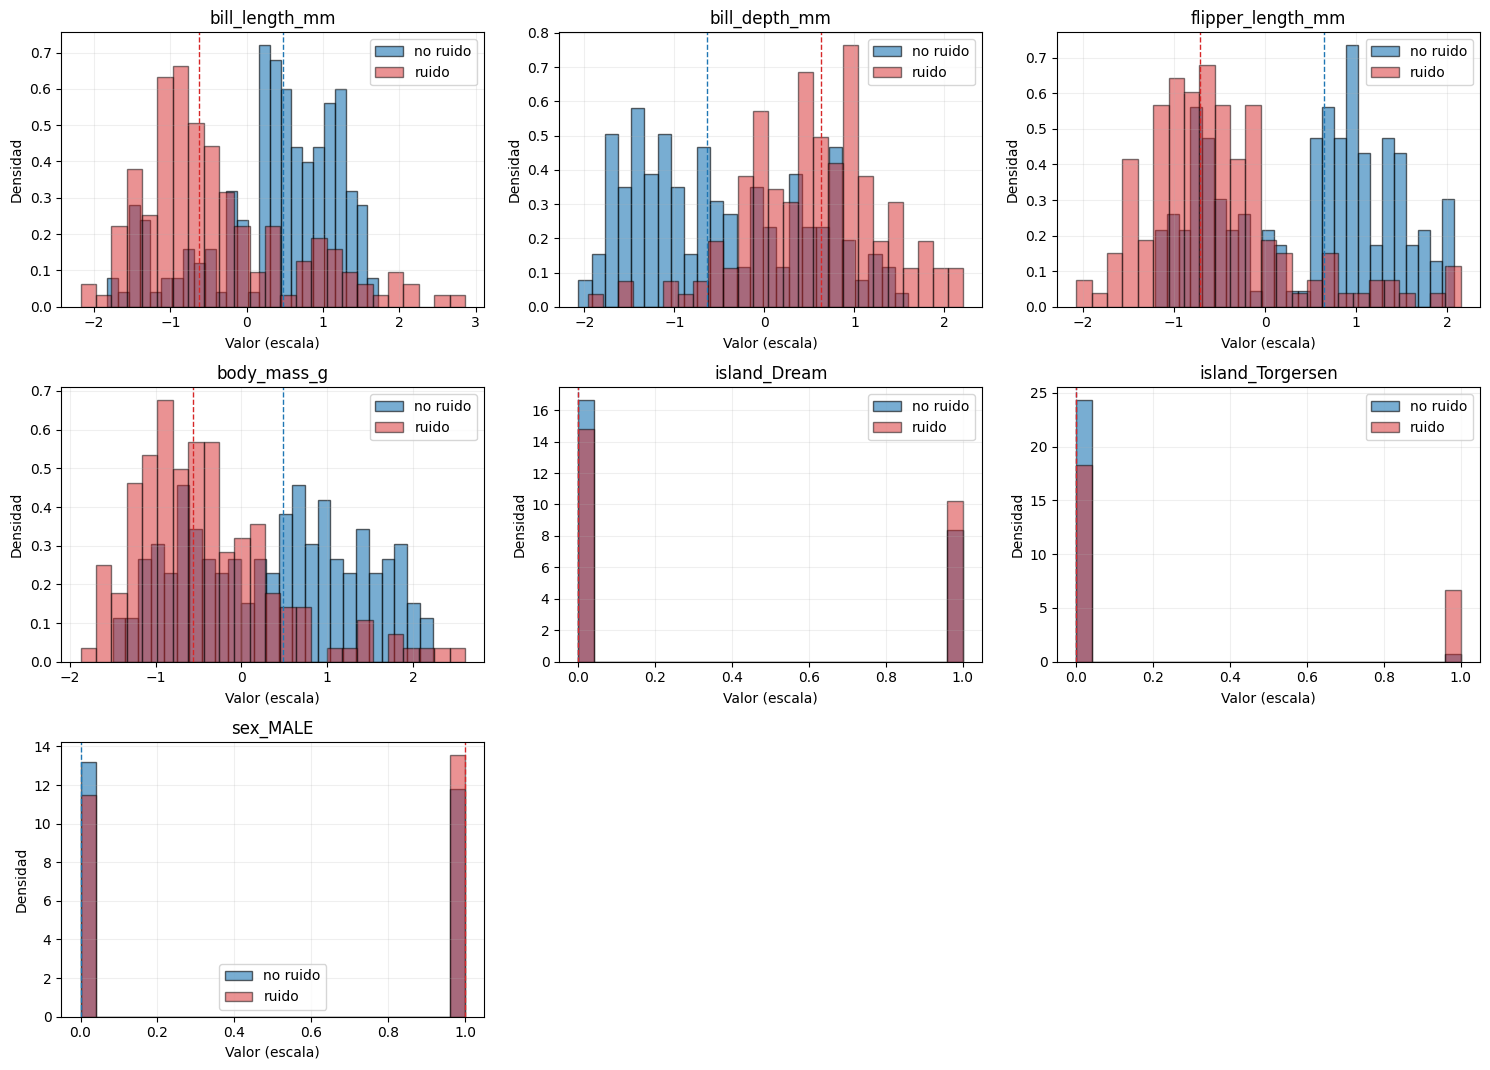

In [13]:
dbscan = DBSCAN(eps = 0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_final)
X_ruido = X_final[np.where(labels_dbscan == -1)[0]]
X_noruido = X_final[np.where(labels_dbscan != -1)[0]]

# Histogramas comparativos: X_ruido vs X_noruido por columna
# Usa nombres de columnas ya existentes (X_numericas + X_onehot)
feature_names = list(X_numericas.columns) + list(X_onehot.columns)
nvars = len(feature_names)

if X_ruido.size == 0:
    print("X_ruido está vacío. No hay datos marcados como ruido.")
else:
    ncols = 3
    nrows = int(np.ceil(nvars / ncols))
    plt.figure(figsize=(ncols * 5, nrows * 3.6))

    for i, name in enumerate(feature_names):
        ax = plt.subplot(nrows, ncols, i + 1)
        # columnas i-ésima de cada matriz
        ruido_col = X_ruido[:, i]
        noruido_col = X_noruido[:, i]

        bins = 25
        ax.hist(noruido_col, bins=bins, density=True, alpha=0.6, label='no ruido', color='C0', edgecolor='k')
        ax.hist(ruido_col, bins=bins, density=True, alpha=0.5, label='ruido', color='C3', edgecolor='k')

        # medianas
        ax.axvline(np.median(noruido_col), color='C0', linestyle='--', linewidth=1)
        ax.axvline(np.median(ruido_col), color='C3', linestyle='--', linewidth=1)

        ax.set_title(name)
        ax.set_xlabel('Valor (escala)')
        ax.set_ylabel('Densidad')
        ax.grid(alpha=0.2)
        ax.legend()

    plt.tight_layout()
    plt.show()